In [95]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# Constants
GRID_SIZE = 4  # 4x4 grid
CELL_SIZE = 28  # Size of each MNIST digit
CANVAS_SIZE = GRID_SIZE * CELL_SIZE  # 112x112 image

# Load MNIST
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Dataset with composed 4x4 grid MNIST images
class GridMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, max_digits=8):
        self.mnist = mnist_dataset
        self.max_digits = max_digits

    def __len__(self):
        return len(self.mnist) // self.max_digits

    def __getitem__(self, idx):
        canvas = torch.zeros(1, CANVAS_SIZE, CANVAS_SIZE)
        positions = list(range(GRID_SIZE * GRID_SIZE))
        random.shuffle(positions)
        num_digits = random.randint(1, self.max_digits)
        selected_positions = positions[:num_digits]
        selected_positions.sort()  # Enforce left-to-right, top-to-bottom

        labels = []
        sub_images = []

        for pos in selected_positions:
            row = pos // GRID_SIZE
            col = pos % GRID_SIZE
            top = row * CELL_SIZE
            left = col * CELL_SIZE

            img_idx = random.randint(0, len(self.mnist) - 1)
            digit_img, label = self.mnist[img_idx]
            canvas[:, top:top+CELL_SIZE, left:left+CELL_SIZE] = digit_img
            labels.append(label)
            sub_images.append(digit_img)

        labels.append(10)  # STOP token
        return canvas, torch.tensor(labels), sub_images



# Reuse your patch creation and collate functions
def create_image_patches(image, patch_size=14):
    patches = []
    img = image.numpy().squeeze()
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    patches = np.array(patches)
    patches = patches.reshape(len(patches), patch_size * patch_size)
    return patches

def collate_fn(batch):
    images = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    patch_list = [create_image_patches(image) for image in images]
    patches = torch.tensor(np.array(patch_list), dtype=torch.float32)
    labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=11)  # e.g., 11 = PAD
    return patches, labels


def show_composed_image(dataset, idx):
    img, labels, sub_images = dataset[idx]

    # Show the composed image
    plt.figure(figsize=(4, 4))
    plt.imshow(img.squeeze(), cmap='gray')
    readable_labels = [str(l.item()) if l.item() < 10 else "STOP" for l in labels]
    plt.title("Composed Image\nDigits: " + ", ".join(readable_labels))
    plt.axis("off")
    plt.show()

    # Show the sub-images in a row
    n = len(sub_images)
    plt.figure(figsize=(n, 1))
    for i, digit_img in enumerate(sub_images):
        plt.subplot(1, n, i + 1)
        plt.imshow(digit_img.squeeze(), cmap='gray')
        plt.title(str(labels[i].item()))
        plt.axis("off")
    plt.suptitle("Sub-images (in reading order)", fontsize=12)
    plt.tight_layout()
    plt.show()



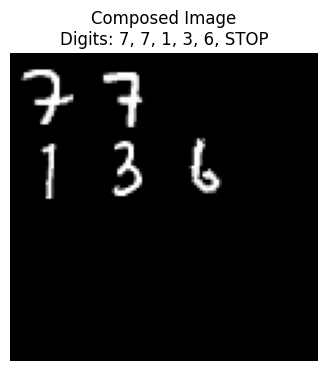

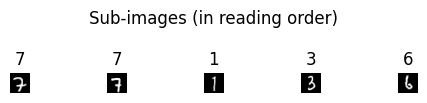

In [98]:
# Create composed train images and dataloader
composed_train = GridMNISTDataset(mnist_train, max_digits=10)
train_loader = DataLoader(composed_train, batch_size=64, shuffle=True, collate_fn=collate_fn)

# Create composed test images and dataloader
composed_test = GridMNISTDataset(mnist_test, max_digits=10)
test_loader = DataLoader(composed_test, batch_size=64, shuffle=False, collate_fn=collate_fn)

# Example usage:
show_composed_image(composed_train, 0)

In [87]:
# Get the first batch from the DataLoader
for batch in train_loader:
    patches, labels = batch
    print(patches.shape)
    print(labels.shape)
    print(labels)
    break


torch.Size([64, 64, 196])
torch.Size([64, 11])
tensor([[ 0,  8,  0,  9,  1,  2,  1,  7,  1,  0, 10],
        [ 1,  2, 10, 11, 11, 11, 11, 11, 11, 11, 11],
        [ 0,  4,  3,  4,  1,  9,  7, 10, 11, 11, 11],
        [ 7,  9,  4,  3,  7,  2,  4,  8,  0,  8, 10],
        [ 3,  7,  4,  8,  6,  9,  8, 10, 11, 11, 11],
        [ 6,  1,  7,  2,  7, 10, 11, 11, 11, 11, 11],
        [ 5,  9, 10, 11, 11, 11, 11, 11, 11, 11, 11],
        [ 4,  1,  1,  4, 10, 11, 11, 11, 11, 11, 11],
        [ 9,  1,  7,  6,  1,  8, 10, 11, 11, 11, 11],
        [ 1,  5,  7,  1,  1,  5, 10, 11, 11, 11, 11],
        [ 7,  1,  2,  8,  2,  3,  8,  7,  9, 10, 11],
        [ 5,  0,  4,  0,  3,  5,  2,  3,  2, 10, 11],
        [ 2,  0,  8,  5,  0,  2, 10, 11, 11, 11, 11],
        [ 6,  6,  8, 10, 11, 11, 11, 11, 11, 11, 11],
        [ 0,  8,  9,  3,  6, 10, 11, 11, 11, 11, 11],
        [ 0,  2,  9,  5,  9, 10, 11, 11, 11, 11, 11],
        [ 5,  4,  8,  9,  9,  7,  4, 10, 11, 11, 11],
        [ 9,  2,  8,  3,  6,  5,  9

In [ ]:
import os

def save_dataset(dataset, save_path):
    """Save the composed MNIST dataset (canvas images and labels)."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    all_canvases = []
    all_labels = []

    for i in range(len(dataset)):
        canvas, labels, _ = dataset[i]
        all_canvases.append(canvas)
        all_labels.append(labels)

    # Pad all labels to the same length
    padded_labels = torch.nn.utils.rnn.pad_sequence(all_labels, batch_first=True, padding_value=11)
    all_canvases = torch.stack(all_canvases)

    torch.save({
        'canvases': all_canvases,
        'labels': padded_labels
    }, save_path)

    print(f"Dataset saved to {save_path}")


def load_dataset_and_loader(load_path, batch_size=64):
    """Load dataset from a .pt file and return a DataLoader using collate_fn."""
    data = torch.load(load_path)
    canvases = data['canvases']
    labels = data['labels']

    class PrecomputedDataset(Dataset):
        def __init__(self, canvases, labels):
            self.canvases = canvases
            self.labels = labels

        def __len__(self):
            return len(self.canvases)

        def __getitem__(self, idx):
            return self.canvases[idx], self.labels[idx], []  # [] = placeholder for sub-images

    dataset = PrecomputedDataset(canvases, labels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return dataloader


save_dataset(composed_train, "train_file")

In [90]:
import torch
import torch.nn as nn

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, emb_dim, num_heads):
        super().__init__()
        assert emb_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        self.q_proj = nn.Linear(emb_dim, emb_dim)
        self.k_proj = nn.Linear(emb_dim, emb_dim)
        self.v_proj = nn.Linear(emb_dim, emb_dim)
        self.out_proj = nn.Linear(emb_dim, emb_dim)

    def forward(self, query, key=None, value=None, mask=None):
        if key is None:
            key = value = query
        B, N, D = query.shape
        q = self.q_proj(query).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(key).reshape(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(value).reshape(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        if mask is not None:
            # mask: (B, 1, N, M) or (1, 1, N, M)
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(attn_scores, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, emb_dim, ff_hidden_dim):
        super().__init__()
        self.MLP = nn.Sequential(
            nn.Linear(emb_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, emb_dim)
        )
    def forward(self, x):
        return self.MLP(x)

class PositionalEncoding(nn.Module):
    def __init__(self, num_positions, emb_dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_positions, emb_dim))
    def forward(self, x):
        return x + self.pos_embedding[:, :x.size(1), :]

class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_hidden_dim):
        super().__init__()
        self.attn = MultiHeadSelfAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim, ff_hidden_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

class TransformerDecoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, ff_hidden_dim):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(emb_dim, num_heads)
        self.cross_attn = MultiHeadSelfAttention(emb_dim, num_heads)
        self.ff = FeedForward(emb_dim, ff_hidden_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.norm3 = nn.LayerNorm(emb_dim)
    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        x = self.norm1(tgt + self.self_attn(tgt, mask=tgt_mask))
        x = self.norm2(x + self.cross_attn(x, key=memory, value=memory, mask=memory_mask))
        x = self.norm3(x + self.ff(x))
        return x

class CustomTransformerEncoderDecoder(nn.Module):
    def __init__(self, patch_dim, emb_dim, num_heads, ff_hidden_dim, num_encoder_layers, num_decoder_layers, num_classes, num_patches, max_seq_length):
        super().__init__()
        # Encoder
        self.patch_proj = nn.Linear(patch_dim, emb_dim)
        self.pos_enc = PositionalEncoding(num_patches, emb_dim)
        self.encoder_blocks = nn.ModuleList([
            TransformerEncoderBlock(emb_dim, num_heads, ff_hidden_dim) for _ in range(num_encoder_layers)
        ])
        # Decoder
        self.tgt_embedding = nn.Embedding(num_classes, emb_dim)
        self.tgt_pos_enc = PositionalEncoding(max_seq_length, emb_dim)
        self.decoder_blocks = nn.ModuleList([
            TransformerDecoderBlock(emb_dim, num_heads, ff_hidden_dim) for _ in range(num_decoder_layers)
        ])
        self.classifier = nn.Linear(emb_dim, num_classes)
        self.max_seq_length = max_seq_length

    def encode(self, x):
        x = self.patch_proj(x)
        x = self.pos_enc(x)
        for block in self.encoder_blocks:
            x = block(x)
        return x

    def decode(self, tgt, memory):
        tgt_emb = self.tgt_embedding(tgt)
        tgt_emb = self.tgt_pos_enc(tgt_emb)
        seq_len = tgt_emb.size(1)
        tgt_mask = self.generate_tgt_mask(seq_len).to(tgt_emb.device)
        x = tgt_emb
        for block in self.decoder_blocks:
            x = block(x, memory, tgt_mask=tgt_mask)
        return x

    def forward(self, x, tgt):
        memory = self.encode(x)
        dec_out = self.decode(tgt, memory)
        return self.classifier(dec_out)

    def generate_tgt_mask(self, seq_len):
        # Causal mask: (1, 1, seq_len, seq_len)
        mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
        return mask

    def generate(self, x, start_token, stop_token, device, max_len=20):
        self.eval()
        memory = self.encode(x)
        generated = [start_token]
        for _ in range(max_len):
            tgt = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)  # (1, cur_len)
            dec_out = self.decode(tgt, memory)
            logits = self.classifier(dec_out)  # (1, cur_len, num_classes)
            next_token = logits[:, -1, :].argmax(-1).item()
            if next_token == stop_token:
                break
            generated.append(next_token)
        return generated[1:]  # Exclude start token


In [104]:
from datetime import datetime
import wandb
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.nn import functional as F

def train_epoch(model, train_loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss = 0
    num_batches = len(train_loader)
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}')
    for batch_idx, (patches, labels) in enumerate(progress_bar):
        # Move data to device
        patches = patches.to(device)  # Shape: [B, N, patch_dim]
        labels = labels.to(device)    # Shape: [B, seq_len]
        
        # Prepare input for decoder (shift right)
        tgt_input = labels[:, :-1]  # Remove last token
        tgt_output = labels[:, 1:]   # Remove first token (start token)
        
        # Forward pass
        optimizer.zero_grad()
        output = model(patches, tgt_input)  # Shape: [B, seq_len-1, num_classes]
        
        # Calculate loss
        loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update metrics
        total_loss += loss.item()
        current_loss = total_loss / (batch_idx + 1)
        
        # Update progress bar
        progress_bar.set_postfix({'loss': f'{current_loss:.4f}'})
        
        # Log to wandb
        wandb.log({
            'batch_loss': loss.item(),
            'running_loss': current_loss,
            'epoch': epoch,
            'batch': batch_idx
        })
    
    epoch_loss = total_loss / num_batches
    return epoch_loss

def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    with torch.no_grad():
        for patches, labels in val_loader:
            patches = patches.to(device)
            labels = labels.to(device)
            
            # Prepare input for decoder
            tgt_input = labels[:, :-1]
            tgt_output = labels[:, 1:]
            
            # Forward pass
            output = model(patches, tgt_input)
            
            # Calculate loss
            loss = criterion(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item()
            
            # Calculate accuracy
            predictions = output.argmax(dim=-1)
            correct_predictions += (predictions == tgt_output).sum().item()
            total_predictions += tgt_output.numel()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct_predictions / total_predictions
    
    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, config):
    """
    Main training function with wandb integration
    
    Args:
        model: The transformer model
        train_loader: Training data loader
        val_loader: Validation data loader
        config: Dictionary containing training configuration
    """

    timestamp = datetime.now().strftime("%H:%M:%S")
    run_name = f"run-{timestamp}"

    # Initialize wandb
    wandb.init(
        entity="emilengdahl",
        project="ImageTransformer",
        config=config,
        name=run_name, reinit=True, id=None
    )
    
    # Setup training
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=11)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config['epochs'],
        eta_min=config['min_lr']
    )
    
    # Training loop
    best_val_loss = float('inf')
    for epoch in range(config['epochs']):
        # Train
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device, epoch)
        
        # Evaluate
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        
        # Log metrics
        wandb.log({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
            'learning_rate': current_lr
        })
        
        # Save best model
        if val_loss < best_val_loss:

            # Save model checkpoint to file
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')

            best_val_loss = val_loss
            artifact = wandb.Artifact('best-model', type='model')
            artifact.add_file('best_model.pth')
            wandb.log_artifact(artifact)
        
        print(f'Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Accuracy = {val_accuracy:.4f}')
    
    wandb.finish()


config = {
    'learning_rate': 1e-4,
    'min_lr': 1e-6,
    'weight_decay': 0.01,
    'epochs': 50,
    'batch_size': 64,
    'num_heads': 8,
    'emb_dim': 256,
    'ff_hidden_dim': 512,
    'num_encoder_layers': 6,
    'num_decoder_layers': 6,
    'patch_dim': 196,  # Changed from 784 to match your actual patch dimension
    'num_classes': 12,  # 10 digits + start/stop tokens
    'max_seq_length': 11,  # Changed to match your actual sequence length
    'num_patches': 64   # Changed to match your actual number of patches
}

# Initialize the model with correct dimensions
model = CustomTransformerEncoderDecoder(
    patch_dim=config['patch_dim'],        # 196
    emb_dim=config['emb_dim'],           # 256
    num_heads=config['num_heads'],        # 8
    ff_hidden_dim=config['ff_hidden_dim'],# 512
    num_encoder_layers=config['num_encoder_layers'],
    num_decoder_layers=config['num_decoder_layers'],
    num_classes=config['num_classes'],    # 12
    num_patches=config['num_patches'],    # 64 (matches your input)
    max_seq_length=config['max_seq_length'] # 11 (matches your label sequence length)
)


train_model(model, train_loader, test_loader, config)


batch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
batch_loss,▇█▆▆▆▆▆▅▆▆▅▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▃▂▂▂▂▁▂▂▂▁
epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,▁
running_loss,██▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
train_loss,▁
val_accuracy,▁
val_loss,▁
batch,93
batch_loss,2.00271
epoch,0


Epoch 0: 100%|██████████| 94/94 [01:04<00:00,  1.45it/s, loss=2.2235]


Epoch 0: Train Loss = 2.2235, Val Loss = 2.0659, Val Accuracy = 0.1334


Epoch 1: 100%|██████████| 94/94 [01:04<00:00,  1.45it/s, loss=2.0450]


Epoch 1: Train Loss = 2.0450, Val Loss = 2.0158, Val Accuracy = 0.1410


...

Epoch 38: Train Loss = 0.1975, Val Loss = 0.2215, Val Accuracy = 0.5090


Epoch 39: 100%|██████████| 94/94 [01:02<00:00,  1.50it/s, loss=0.1861]


Epoch 39: Train Loss = 0.1861, Val Loss = 0.2061, Val Accuracy = 0.5260


Epoch 40:  19%|█▉        | 18/94 [00:13<00:58,  1.30it/s, loss=0.1951]


KeyboardInterrupt: 